# The Climate is Changing: How is Our Sentiment?

## Exploring Changing Sentiment in Climate Articles: 2013 to 2023

#### This is a notebook for extracting and organizing data from XML files. Authorship credit to Rafael Alvarado at the University of Virginia; modifications by Caroline Kranefuss, also at the University of Virginia.

## Corpus Description

9 scientific articles are drawn from PeerJ's publications in the decade spanning 2013 to 2023 (3 from 2013, 3 from 2018, and 3 from 2023). Articles are filtered so as to have 50 or more citations, and are sorted by PeerJ's determination of relevance to the query "climate." The top 3 most relevant articles, after meeting these described criteria, have then been chosen to comprise my corpus.

## Imports

In [21]:
# General imports
import pandas as pd 
import numpy as np 
import os
import sys

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Project-specific imports
import glob
from lxml import etree
from glob import glob
import re
import nltk
nltk_resources = [
    'tokenizers/punkt', 
    'averaged_perceptron_tagger_eng',
    'corpora/stopwords', 
    'help/tagsets'
]

for resource in nltk_resources:
    try:
        nltk.data.find(resource)
    except LookupError:
        nltk.download(resource)


# ----File Stitching----
# If not in repo home folder, cd back 
if os.path.basename(os.getcwd()) != "evolving_sentiment_climate":
    os.chdir('..')
# If a file is in /sources/, access it by telling the system to look at that path as well as current path
sys.path.append(os.path.join(os.getcwd(), '..', 'sources'))
source_dir = "sources"
source_files_paths = glob(f"{source_dir}/*.xml")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\student\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


## Creating DOC Table

In [2]:
# Downloading files 
source_dir = "sources"
source_files_paths = glob(f"{source_dir}/*.xml")

# Iterate through files, grab XML info, and save to a dictionary
docs = []
for i, source_file_path in enumerate(source_files_paths):

    tree = etree.parse(source_file_path)
    root = tree.getroot()
    
    pub_id_str = root.xpath("//front//article-meta//article-id")[1].text

    title_el = root.xpath("//front//article-title")[0]
    title_str = " ".join([t.strip() for t in title_el.itertext()])

    year_str = root.xpath("//front//pub-date/year")[0].text
    month_str = root.xpath("//front//pub-date/month")[0].text
    day_str = root.xpath("//front//pub-date/day")[0].text
    date_str = "-".join([year_str, month_str, day_str])

    kwd_els = root.xpath("//kwd")
    kwd_strs = [kwd_el.text for kwd_el in kwd_els]

    p_els = root.xpath("//body//p")
    p_strs = []
    for p_el in p_els:
        etree.strip_elements(p_el, "xref", with_tail=False)
        p_str = etree.tostring(p_el, method="text", encoding="unicode")
        p_strs.append(p_str)
    
    docs.append({
        'doc_id': pub_id_str,
        'doc_title': title_str,
        'doc_date': date_str,
        'doc_content': " ".join(p_strs),
        'doc_kws': kwd_strs,
        'doc_file_path': source_file_path
    })

# Convert dictionary to data frame
DOC = pd.DataFrame(docs) 
del(docs)
DOC

,doc_id,doc_title,doc_date,doc_content,doc_kws,doc_file_path
0,10.7717/peerj-cs.1306,Artificial intelligence-assisted air quality m...,2023-5-24,Our environment has been greatly impacted by r...,"[AI, Air quality monitoring, Smart cities, Sus...",sources\Artificial_intelligence_2023.xml
1,10.7717/peerj-cs.1705,Blockchain technology and application: an over...,2023-11-29,Blockchain is a tamper-proof distributed ledge...,"[Blockchain technology, IoT, Consensus mechani...",sources\Blockchain_technology_2023.xml
2,10.7717/peerj.183,Citations and the h index of soil researchers ...,2013-10-22,Scientific impact measures are increasingly be...,"[Soil science, Bibliometrics, None, Impact fac...",sources\Citations_2013.xml
3,10.7717/peerj.5885,Effects of waste stream combinations from brew...,2018-11-28,The United Nations figures project global huma...,"[None, Protein quality, Net energy, Mass reari...",sources\Effects_of_waste_2018.xml
4,10.7717/peerj-cs.1657,Integration of federated learning with IoT for...,2023-12-6,Nobody wants unauthorized access to their data...,"[AI, Smart grid, Federated learning, Internet ...",sources\Integration_of_federated_2023.xml
5,10.7717/peerj.163,Microgeographic maladaptive performance and de...,2013-9-17,Identifying informative scales and levels of b...,"[Microgeographic differentiation, Adaptation a...",sources\Microgeographic _2013.xml
6,10.7717/peerj.5827,Seasonal and predator-prey effects on circadia...,2018-11-21,Animal activity patterns are influenced by a v...,"[Temporal co-occurrence, Mammal species, Circa...",sources\Seasonal_2018.xml
7,10.7717/peerj.6030,Structural plasticity in root-fungal symbioses...,2018-12-4,Early terrestrial plants moved from aquatic en...,"[Mycorrhiza, Endophyte, Symbiosis, Root coloni...",sources\Structural_plasticity_2018.xml
8,10.7717/peerj.151,Typhoon damage on a shallow mesophotic reef in...,2013-9-3,Typhoon damage from direct physical disturbanc...,"[Coral reef, Mesophotic, Typhoon damage, Succe...",sources\Typhoon_2013.xml


In [3]:
DOC['year'] = DOC['doc_date'].str[:4]
DOC['mth_day'] = DOC['doc_date'].str[5:]
DOC = DOC.copy()
DOC_to_join = DOC.drop(columns=['doc_id', 'doc_title', 'doc_date', 'doc_content', 'doc_kws', 'doc_file_path'])
DOC_to_join.index.rename('doc_id', inplace=True)
DOC_to_join

,year,mth_day
doc_id,,
0,2023,5-24
1,2023,11-29
2,2013,10-22
3,2018,11-28
4,2023,12-6
5,2013,9-17
6,2018,11-21
7,2018,12-4
8,2013,9-3


In [4]:
# Parse into Sentences with NLTK
SENTS = DOC.doc_content.apply(lambda x: pd.Series(nltk.sent_tokenize(x), dtype='string')).stack().to_frame('sent_str')
SENTS = SENTS.sent_str[SENTS.sent_str.apply(lambda x: isinstance(x, str))] # From Claude
SENTS.index.names = ['doc_id','sent_num']
SENTS = SENTS.to_frame()
SENTS

sent_str
doc_id sent_num                                                   
0      0         Our environment has been greatly impacted by r...
       1         There are serious threats posed by climate cha...
       2         This alarming situation has arisen due to the ...
       3         With the urban space expansion, increasing use...
       4         From a health perspective, urban air pollution...
...                                                            ...
8      96        A potential increase in storms makes it even m...
       97        This study has shown that despite their depth,...
       98        It is, therefore, critical to document the suc...
       99        Coral species and functional groups (documente...
       100       Functional groups: 1, massive; 2, encrusting; ...

[2659 rows x 1 columns]

### Creating TOKENS Table

In [5]:
# Parse into Tokens with NLTK
TOKENS = SENTS.sent_str.apply(lambda x: pd.Series(nltk.pos_tag(nltk.word_tokenize(x)))).stack().to_frame('pos_tuple')
TOKENS = TOKENS.dropna()
TOKENS['pos'] = TOKENS.pos_tuple.apply(lambda x: x[1])
TOKENS['pos_group'] = TOKENS.pos.str[:2]
TOKENS['token_str'] = TOKENS.pos_tuple.apply(lambda x: x[0])
TOKENS = TOKENS.drop('pos_tuple', axis=1)
TOKENS['term_str'] = TOKENS.token_str.str.lower().str.replace(r"[\W_]+", "", regex=True) 
TOKENS = TOKENS[TOKENS.term_str != ''].copy()
TOKENS.index.names = SENTS.index.names + ['token_num']
TOKENS

pos pos_group    token_str     term_str
doc_id sent_num token_num                                          
0      0        0          PRP$        PR          Our          our
                1            NN        NN  environment  environment
                2           VBZ        VB          has          has
                3           VBN        VB         been         been
                4            RB        RB      greatly      greatly
...                         ...       ...          ...          ...
8      100      25           NN        NN        bushy        bushy
                27           CD        CD            7            7
                29           NN        NN  arborescent  arborescent
                31           CD        CD            8            8
                33          VBN        VB   unattached   unattached

[58719 rows x 4 columns]

In [6]:
TOKENS = TOKENS.join(DOC_to_join)
TOKENS = TOKENS.set_index('year', append=True)
TOKENS = TOKENS.set_index('mth_day', append=True)
TOKENS = TOKENS.reorder_levels([3,4,0,1,2])
TOKENS

pos pos_group    token_str  \
year mth_day doc_id sent_num token_num                                
2023 5-24    0      0        0          PRP$        PR          Our   
                             1            NN        NN  environment   
                             2           VBZ        VB          has   
                             3           VBN        VB         been   
                             4            RB        RB      greatly   
...                                      ...       ...          ...   
2013 9-3     8      100      25           NN        NN        bushy   
                             27           CD        CD            7   
                             29           NN        NN  arborescent   
                             31           CD        CD            8   
                             33          VBN        VB   unattached   

                                           term_str  
year mth_day doc_id sent_num token_num               
2023 5-24    0      0        0                  our  
                             1          environment  
                             2                  has  
                             3                 been  
                             4              greatly  
...                                             ...  
2013 9-3     8      100      25               bushy  
                             27                   7  
                             29         arborescent  
                             31                   8  
                             33          unattached  

[58719 rows x 4 columns]

In [7]:
# TOKEN = DOC.doc_content.str.split(expand=True).stack().to_frame("token_str")
# TOKEN.index.names = ['doc_id','token_num']
# TOKEN['term_str'] = TOKEN.token_str.str.lower().str.replace(r"[^a-z]+", "", regex=True)
# TOKEN = TOKEN[~(TOKEN.term_str == "")]
# TOKEN

### Creating Keywords Table

In [8]:
DOCKW = DOC.doc_kws.apply(pd.Series).stack().to_frame('doc_kw')
DOCKW.index.names = ['doc_id', 'kw_num']
DOCKW.head()

doc_kw
doc_id kw_num                        
0      0                           AI
       1       Air quality monitoring
       2                 Smart cities
       3               Sustainability
       4       Air quality management

In [12]:
KW = DOCKW.doc_kw.value_counts().to_frame('n')
KW.head()

,n
doc_kw,
AI,2
Air quality monitoring,1
Smart cities,1
Sustainability,1
Air quality management,1


### Create VOCAB Table

First remove stopwords. Then, group by year to draw temporal conclusions.

# Remove stopwords here

In [35]:
VOCAB = TOKENS.term_str.groupby(level='year').value_counts().to_frame('n')
VOCAB.index.name = 'term_str'
# Get overall probability (not as useful)
VOCAB['p'] = VOCAB.n / VOCAB.n.sum()
# Get probability per year
years = ['2013', '2018', '2023']
for year in years:
    VOCAB.loc[year,'p_yr'] = VOCAB.n / VOCAB.loc[year].n.sum()
VOCAB

n         p      p_yr
year term_str                            
2013 the          688  0.011717  0.055799
     of           470  0.008004  0.038118
     and          355  0.006046  0.028792
     in           271  0.004615  0.021979
     to           267  0.004547  0.021655
...               ...       ...       ...
2023 concise        1  0.000017  0.000037
     deeper         1  0.000017  0.000037
     delve          1  0.000017  0.000037
     authorizing    1  0.000017  0.000037
     links          1  0.000017  0.000037

[9816 rows x 3 columns]

### Visualization #1: Word Frequency Distributions by Year

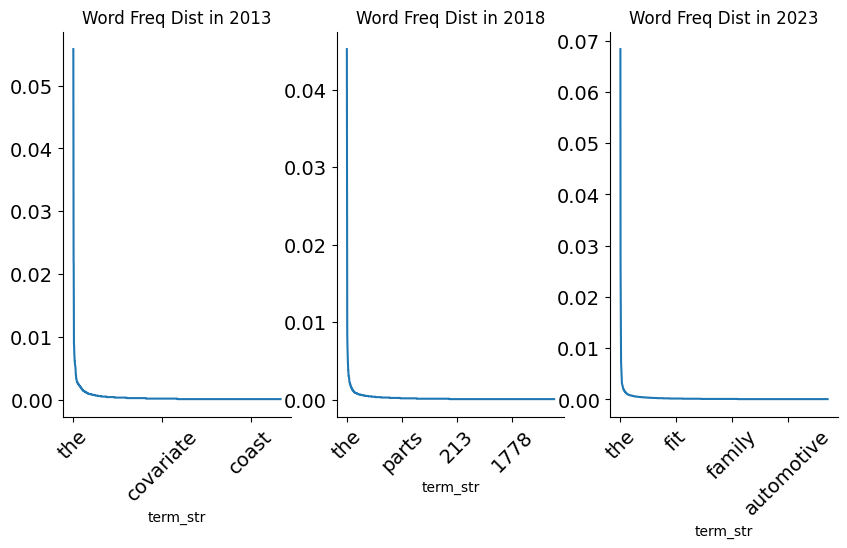

In [45]:
fig1, axes = plt.subplots(1,3)
for i, year in enumerate(years):
    VOCAB.loc[year].p_yr.plot(ax=axes[i], figsize=(10,5), fontsize=14, rot=45, legend=False, title=f"Word Freq Dist in {year}")
sns.despine()
plt.show()

### Visualization #2: Most Frequent Words by Year

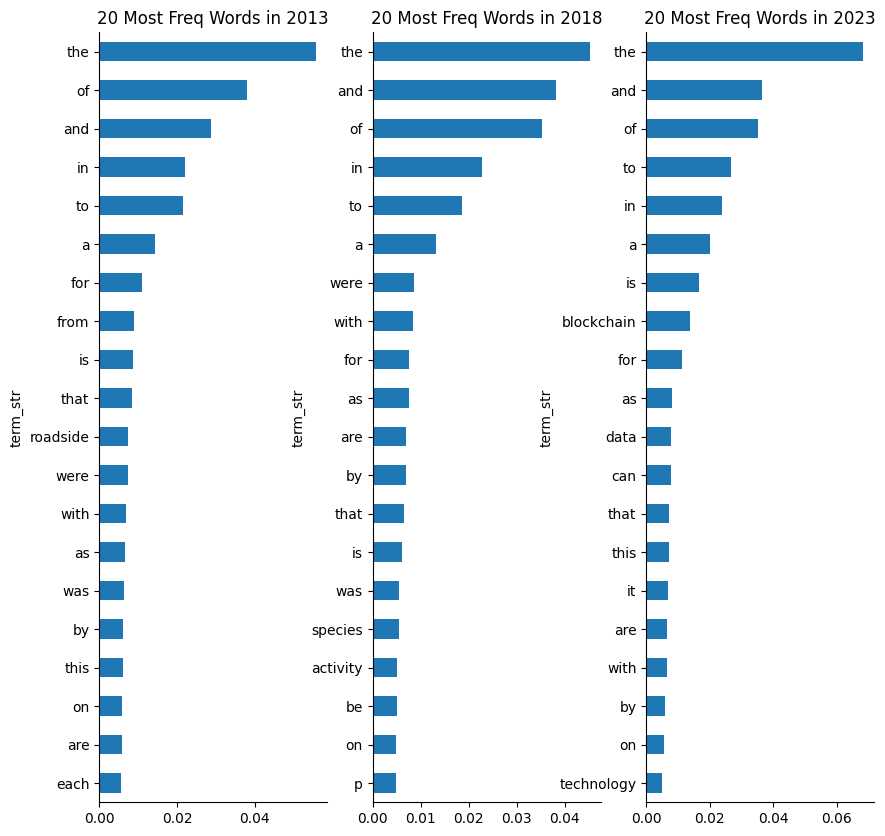

In [47]:
fig2, axes = plt.subplots(1,3)
for i, year in enumerate(years):
    VOCAB.loc[year].p_yr.head(20).sort_values().plot.barh(ax=axes[i], figsize=(10,10), title=f"20 Most Freq Words in {year}")
sns.despine()
plt.show()